#**Import Libraries, Mount Your Drive, and Load in Your Data**

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
# Set pandas as the default output for sklearn
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:

fpath = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week04/Data/ames-housing-for-ml.csv"

In [ ]:
df = pd.read_csv(fpath)
df = df.set_index("PID")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 907227090 to 902201120
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MS Zoning         2930 non-null   object 
 1   Lot Frontage      2440 non-null   float64
 2   Lot Area          2930 non-null   int64  
 3   Street            2930 non-null   object 
 4   Alley             198 non-null    object 
 5   Utilities         2930 non-null   object 
 6   Neighborhood      2930 non-null   object 
 7   Bldg Type         2930 non-null   object 
 8   House Style       2930 non-null   object 
 9   Overall Qual      2930 non-null   int64  
 10  Overall Cond      2930 non-null   int64  
 11  Year Built        2930 non-null   int64  
 12  Year Remodeled    2930 non-null   int64  
 13  Exter Qual        2930 non-null   object 
 14  Exter Cond        2930 non-null   object 
 15  Bsmt Unf Sqft     2929 non-null   float64
 16  Total Bsmnt Sqft  2929 non-null   

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,...,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths,Total Full Baths
PID,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,...,297.0,TA,TA,Y,MnPrv,119900.0,3,2006,0.0,1.0
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,...,576.0,TA,TA,Y,NaN,320000.0,3,2006,1.0,3.0
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,...,301.0,TA,TA,Y,NaN,151500.0,4,2007,0.0,1.0
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,...,1220.0,TA,TA,Y,NaN,385000.0,6,2008,0.0,3.0
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,...,476.0,TA,TA,Y,NaN,193800.0,2,2007,0.0,3.0


##**Preprocess the Data**

**Define X and y, and train test split**

In [ ]:
# Make a list of features to drop
drop_from_model = ['Utilities', # Quasi-constant
                   "Street", # Quasi-constant
                   'MS Zoning', # Stakeholder can't change
                   'Lot Frontage',  # Stakeholder can't change
                   'Lot Area', # Stakeholder can't change
                   'Neighborhood',  # Stakeholder can't change
                   'Year Built'] # Stakeholder can't change

# Define features matrix
X = df.drop(columns = [*drop_from_model,'SalePrice'])

# Define target
y = df['SalePrice']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
# Preview training data
X_train.head()

,Alley,Bldg Type,House Style,Overall Qual,Overall Cond,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,...,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Month,Year,Total Half Baths,Total Full Baths
PID,,,,,,,,,,,,,,,,,,,,,
905475520,NaN,1Fam,1Story,4,5,1994,TA,TA,0.0,0.0,...,1.0,308.0,TA,TA,N,NaN,8,2007,0.0,1.0
909254010,NaN,1Fam,2Story,7,8,1990,TA,TA,600.0,600.0,...,1.0,215.0,Fa,TA,Y,MnPrv,5,2009,0.0,1.0
531450090,NaN,1Fam,1Story,6,5,1991,TA,TA,78.0,1278.0,...,2.0,496.0,TA,TA,Y,GdWo,6,2008,0.0,3.0
903400040,Pave,1Fam,2Story,6,6,1950,TA,TA,764.0,764.0,...,2.0,520.0,TA,TA,N,GdPrv,7,2007,0.0,1.0
527107130,NaN,1Fam,SLvl,7,5,1997,TA,TA,100.0,384.0,...,2.0,390.0,TA,TA,Y,NaN,6,2009,1.0,2.0


#**Make Preprocessing Pipelines for each Feature Type**

In [ ]:
# PREPROCESSING PIPELINE FOR NUMERIC DATA
# Save list of column names
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
# instantiate preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
# Making a numeric tuple for ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Overall Qual', 'Overall Cond', 'Year Remodeled', 'Bsmt Unf Sqft',
       'Total Bsmnt Sqft', 'Living Area Sqft', 'Bedroom', 'Kitchen',
       'Total Rooms', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Month',
       'Year', 'Total Half Baths', 'Total Full Baths'],
      dtype='object')


In [ ]:
# PREPROCESSING PIPELINE FOR ORDINAL DATA
# Save list of column names
ord_cols = ['Exter Qual','Exter Cond', 'Garage Qual',"Garage Cond"]
print("Ordinal Columns:", ord_cols)
# Create imputer for ordinal data
impute_na_ord = SimpleImputer(strategy='constant', fill_value='NA')
# Making the OrdinalEncoder
# Specifying order of categories for our  Ordinal Qual/Cond Columms
qual_cond_order = ['NA','Po', 'Fa', 'TA', 'Gd', 'Ex']
# Making the list of order lists for OrdinalEncoder
ordinal_category_orders = [qual_cond_order, qual_cond_order,
                           qual_cond_order, qual_cond_order]
ord_encoder = OrdinalEncoder(categories=ordinal_category_orders)
# Making a final scaler to scale category #'s
scaler_ord = StandardScaler()
# Making an ord_pipe
ord_pipe = make_pipeline(impute_na_ord, ord_encoder, scaler_ord)
# Making an ordinal_tuple for ColumnTransformer
ord_tuple = ('ordinal', ord_pipe, ord_cols)

Ordinal Columns: ['Exter Qual', 'Exter Cond', 'Garage Qual', 'Garage Cond']


In [ ]:
# PREPROCESSING PIPELINE FOR ONE-HOT-ENCODED DATA
# Save list of column names
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='constant', fill_value = "NA")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
# Making a ohe_tuple for ColumnTransformer
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['Alley', 'Bldg Type', 'House Style', 'Central Air', 'Garage Type',
       'Paved Drive', 'Fence'],
      dtype='object')


##**Create and Fit the Column Transformer**

In [ ]:
# Create the Column Transformer
col_transformer = ColumnTransformer([num_tuple, ord_tuple, ohe_tuple],
                                    verbose_feature_names_out=False)
# Fit on training data
col_transformer.fit(X_train)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Overall Qual', 'Overall Cond', 'Year Remodeled', 'Bsmt Unf Sqft',
       'Total Bsmnt Sqft', 'Living Area Sqft', 'Bedroom', 'Kitchen',
       'Total Rooms', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Month',
       'Year', 'Total Half Baths...
                                 ['Exter Qual', 'Exter Cond', 'Garage Qual',
                                  'Garage Cond']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Alley', 'Bldg Type', 'House Style', 'Central Air', 'Garage Type',
       'Paved Drive', 'Fence'],
      dtype='object'))],
                  verbose_feature_names_out=False)

#**Transform the Data**

In [ ]:
X_train_tf = col_transformer.transform(X_train)
# Transform the testing data
X_test_tf = col_transformer.transform(X_test)
# View the processed training data
X_train_tf.head()

,Overall Qual,Overall Cond,Year Remodeled,Bsmt Unf Sqft,Total Bsmnt Sqft,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Yr Blt,...,Garage Type_Detchd,Garage Type_NA,Paved Drive_N,Paved Drive_P,Paved Drive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NA
PID,,,,,,,,,,,,,,,,,,,,,
905475520,-1.453681,-0.502192,0.472590,-1.282165,-2.329907,-1.086450,0.183403,-0.203499,-0.909803,-0.820130,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
909254010,0.648845,2.193205,0.282376,0.093593,-0.996395,-0.525568,0.183403,-0.203499,-0.275453,-2.455923,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
531450090,-0.051997,-0.502192,0.329930,-1.103317,0.510475,-0.395679,0.183403,-0.203499,-0.275453,0.529399,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
903400040,-0.051997,0.396274,-1.619758,0.469633,-0.631901,0.647364,0.183403,-0.203499,0.993247,-1.556237,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
527107130,0.648845,-0.502192,0.615250,-1.052872,-1.476459,0.261635,0.183403,-0.203499,0.358897,0.733873,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


#**Default Decision Tree Regressor**

**1) Instantiate the Model**

In [ ]:
# For reproducible results, set the random state
dec_tree = DecisionTreeRegressor(random_state = 42)

**2) Fit the Model on Training Data**

In [ ]:
# Fit the model on the training data only
dec_tree.fit(X_train_tf, y_train)

DecisionTreeRegressor(random_state=42)

**3) Make Predictions on Training and Test Data**

In [ ]:
# Make predictions for training and testing data
train_preds = dec_tree.predict(X_train_tf)
test_preds = dec_tree.predict(X_test_tf)

**4) Evaluate the Model**

In [ ]:
# Evaluate the model
train_r2_score = r2_score(y_train, train_preds)
test_r2_score = r2_score(y_test, test_preds)
# Print the results
print (f'Training R2 is {train_r2_score:.3f}.')
print (f'Testing R2 is {test_r2_score:.3f}.')

Training R2 is 1.000.
Testing R2 is 0.671.


##**Tuning the Model**

In [ ]:
# Looking at options for tuning this model
dec_tree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [ ]:
# What was the depth of our default tree?
dec_tree.get_depth()

27

##**Finding the Optimal max_depth (hyperparameter tuning)**

In [ ]:
# Let's go extreme and set our max depth to 2
dec_tree_2 = DecisionTreeRegressor(max_depth = 2, random_state = 42)
# Fit on training data
dec_tree_2.fit(X_train_tf, y_train)
# Get predictions
train_preds = dec_tree_2.predict(X_train_tf)
test_preds = dec_tree_2.predict(X_test_tf)
# Calculate r2 score
train_2_score = r2_score(y_train, train_preds)
test_2_score = r2_score(y_test, test_preds)
# Print results
print (f'Training R2 is {train_2_score:.3f}.')
print (f'Testing R2 is {test_2_score:.3f}.')

Training R2 is 0.660.
Testing R2 is 0.578.


In [ ]:
# Instantiate model with max_depth of 10
dec_tree_10 = DecisionTreeRegressor(max_depth = 10, random_state = 42)
# Fit on training data
dec_tree_10.fit(X_train_tf, y_train)
# Get predictions
train_preds = dec_tree_10.predict(X_train_tf)
test_preds = dec_tree_10.predict(X_test_tf)
# Calculate r2 score
train_10_score = r2_score(y_train, train_preds)
test_10_score = r2_score(y_test, test_preds)
# Print results
print (f'Training R2 is {train_10_score:.3f}.')
print (f'Testing R2 is {test_10_score:.3f}.')

Training R2 is 0.975.
Testing R2 is 0.690.


In [ ]:
# List of values to try for max_depth:
depths = list(range(2, 27)) # will try every value between 2 and 27
# list to collect the results of each depth
scores_list = []
# Loop through depths
for depth in depths:
    dec_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dec_tree.fit(X_train_tf, y_train)
    # Get predictions
    train_preds = dec_tree.predict(X_train_tf)
    test_preds = dec_tree.predict(X_test_tf)
    # Calculate score
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    # Add dictionray of scores to score_list
    results = {'max_depth':depth,
               'Train R2':train_r2,
               'Test R2':test_r2}
    scores_list.append(results)
    # Print the results
    print(f'When max_depth is {depth},')
    print(f'- the training R2 is {train_r2:.3f}.')
    print(f'- the testing R2 is {test_r2:.3f}.')
    print()

When max_depth is 2,
- the training R2 is 0.660.
- the testing R2 is 0.578.

When max_depth is 3,
- the training R2 is 0.750.
- the testing R2 is 0.670.

When max_depth is 4,
- the training R2 is 0.814.
- the testing R2 is 0.727.

When max_depth is 5,
- the training R2 is 0.861.
- the testing R2 is 0.695.

When max_depth is 6,
- the training R2 is 0.894.
- the testing R2 is 0.699.

When max_depth is 7,
- the training R2 is 0.922.
- the testing R2 is 0.697.

When max_depth is 8,
- the training R2 is 0.945.
- the testing R2 is 0.703.

When max_depth is 9,
- the training R2 is 0.963.
- the testing R2 is 0.703.

When max_depth is 10,
- the training R2 is 0.975.
- the testing R2 is 0.690.

When max_depth is 11,
- the training R2 is 0.984.
- the testing R2 is 0.684.

When max_depth is 12,
- the training R2 is 0.990.
- the testing R2 is 0.681.

When max_depth is 13,
- the training R2 is 0.993.
- the testing R2 is 0.673.

When max_depth is 14,
- the training R2 is 0.995.
- the testing R2 is 0.

In [ ]:
# Create a dataframe from the scores_list
scores = pd.DataFrame(scores_list)
# Set the max_depth as the index
scores = scores.set_index('max_depth')
scores.head()

,Train R2,Test R2
max_depth,,
2,0.659758,0.577829
3,0.749603,0.670419
4,0.813764,0.727450
5,0.860900,0.695466
6,0.894339,0.699080


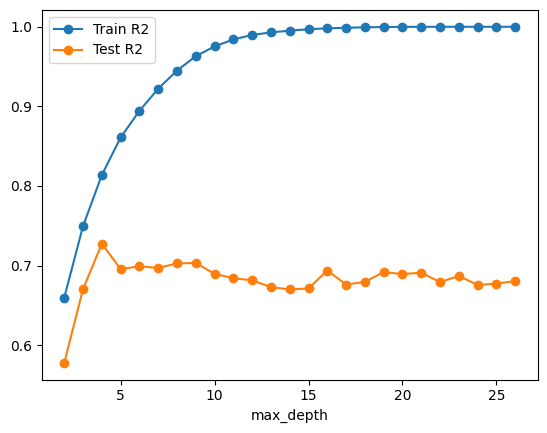

In [ ]:
# Plot the results for the train and test data
ax = scores.plot(marker='o')
ax.legend();

In [ ]:
# Sort by best result on the test data
sorted_scores = scores.sort_values(by='Test R2', ascending=False)
sorted_scores.head()

,Train R2,Test R2
max_depth,,
4,0.813764,0.727450
9,0.963094,0.703225
8,0.944933,0.702677
6,0.894339,0.699080
7,0.922196,0.696967


In [ ]:
# Let's run the model with our optimized value for max_depth
dec_tree_4 = DecisionTreeRegressor(max_depth = 4, random_state = 42)
# Fit on the training data
dec_tree_4.fit(X_train_tf, y_train)
# Get predictions
train_preds = dec_tree_4.predict(X_train_tf)
test_preds = dec_tree_4.predict(X_test_tf)
# Calculate score
train_4_score = r2_score(y_train, train_preds)
test_4_score = r2_score(y_test, test_preds)
# Print results
print (f'Training R2 is {train_4_score:.3f}.')
print (f'Testing R2 is {test_4_score:.3f}.')

Training R2 is 0.814.
Testing R2 is 0.727.
